# Optimization results plotter


In [1]:
import zipfile
from pathlib import Path
import io
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib import colors

## INPUT DATA

Specify zip file location

In [2]:
zipfile_path = Path("../../log/run_results_ede8494b_2026-05-12_16-47-28_COMPLETED.zip")  # Update this path to your ZIP file
print(zipfile_path.resolve())

# Specify search bounds from optimization configuration
search_xmin, search_xmax = 1250.0, 3750.0
search_ymin, search_ymax = 800.0, 3200.0


/home/kurgyisk/projects/URGENT_RiskManagementToolbox/log/run_results_ede8494b_2026-05-12_16-47-28_COMPLETED.zip


## HELPERS for data import

Code reads in control_vector_logger.csv from specified zip file.

Column tracking currently looks for the following column headers is control_vector file:

- generation
- individual --> population ID within generation
- well_design#INJ#wellhead#x and well_design#INJ#wellhead#y
- well_design#PROD#wellhead#x and well_design#PROD#wellhead#y
- Heat --> objective function name

In [3]:
## Helper functions for loading control_vector_logger.csv from ZIP archives

def find_control_logger_in_zip(zip_path, target_name):
    """
    Find and open the control_vector_logger.csv file inside a zip archive.
    Returns a file-like object.
    """
    zip_path = Path(zip_path)

    if not zip_path.exists():
        raise FileNotFoundError(f"ZIP file not found: {zip_path}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        members = zf.namelist()

        # Exact basename match
        exact_matches = [m for m in members if Path(m).name.lower() == target_name.lower()]
        if exact_matches:
            with zf.open(exact_matches[0]) as f:
                data = f.read()
            return io.BytesIO(data), exact_matches[0]

    raise FileNotFoundError(
        f"Could not find '{target_name}' control logger CSV inside {zip_path}"
    )

def load_control_vector_logger(zip_path, target_name="control_vector_logger.csv"):
    """
    Read control_vector_logger.csv from zip into a dataframe.
    """
    file_obj, member_name = find_control_logger_in_zip(zip_path, target_name)
    df = pd.read_csv(file_obj)
    print(f"Loaded '{member_name}' from ZIP archive.")
    print("Columns found:")
    print(list(df.columns))
    return df

## Helper function for extracting base case and optimized case data from the dataframe

def extract_special_cases(df, cols):
    """
    Extract:
    - base case: generation 0, population/individual 0
    - optimized case: row with maximum objective value
    """
    gen_col = cols["generation"]
    pop_col = cols["population"]
    obj_col = cols["objective"]

    # base case
    if pop_col is None:
        raise ValueError(
            "Could not identify the population/individual column automatically. "
            "Please specify it manually in cols['population']."
        )

    base_case = df[(df[gen_col] == 0) & (df[pop_col] == 0)]
    if base_case.empty:
        raise ValueError("Could not find base case row with generation=0 and population=0.")
    base_case = base_case.iloc[0]

    # optimized case = highest heat
    best_idx = df[obj_col].idxmax()
    optimized_case = df.loc[best_idx]

    return base_case, optimized_case

## Helper functions for column matching

def normalize_name(name):
    """
    Normalize column names for easier matching.
    """
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def find_column(df, candidates, required=True):
    """
    Find a column in df whose normalized name matches one of the candidate patterns.
    Candidates can be exact normalized names or substrings.
    """
    norm_map = {col: normalize_name(col) for col in df.columns}

    # Exact match first
    for candidate in candidates:
        cand_norm = normalize_name(candidate)
        for col, norm_col in norm_map.items():
            if norm_col == cand_norm:
                return col

    # Substring match second
    for candidate in candidates:
        cand_norm = normalize_name(candidate)
        for col, norm_col in norm_map.items():
            if cand_norm in norm_col:
                return col

    if required:
        raise KeyError(
            f"Could not find a matching column for any of these candidates: {candidates}\n"
            f"Available columns are:\n{list(df.columns)}"
        )
    return None


def infer_required_columns(df):
    cols = {
        "generation": find_column(df, ["generation"]),
        "population": find_column(df, ["individual"], required=False),
        "inj_x": find_column(df, ["well_design#INJ#wellhead#x"]),
        "inj_y": find_column(df, ["well_design#INJ#wellhead#y"]),
        "prod_x": find_column(df, ["well_design#PROD#wellhead#x"]),
        "prod_y": find_column(df, ["well_design#PROD#wellhead#y"]),
        "objective": find_column(df, ["Heat"]),
    }
    return cols


# Helper functions for loading generation_summary.csv from ZIP file

def find_csv_in_zip(zip_path, target_name):
    zip_path = Path(zip_path)

    if not zip_path.exists():
        raise FileNotFoundError(f"ZIP file not found: {zip_path}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        members = zf.namelist()

        exact_matches = [m for m in members if Path(m).name.lower() == target_name.lower()]
        if exact_matches:
            with zf.open(exact_matches[0]) as f:
                data = f.read()
            return io.BytesIO(data), exact_matches[0]

        similar_matches = [
            m for m in members
            if target_name.replace(".csv", "").lower() in Path(m).name.lower() and m.lower().endswith(".csv")
        ]
        if similar_matches:
            with zf.open(similar_matches[0]) as f:
                data = f.read()
            return io.BytesIO(data), similar_matches[0]

    raise FileNotFoundError(f"Could not find '{target_name}' inside {zip_path}")


def load_generation_summary(zip_path):
    best_file, best_member = find_csv_in_zip(zip_path, target_name="best_result_logger.csv")
    stat_file, stat_member = find_csv_in_zip(zip_path, target_name="population_statistic_logger.csv")
    df_best = pd.read_csv(best_file)
    df_stat = pd.read_csv(stat_file)
    print(f"Loaded best result logger: {best_member}")
    print(f"Loaded population statistic logger: {stat_member}")

    # Safety checks
    if "generation" not in df_best.columns:
        raise KeyError(f"'generation' column not found in {best_member}")

    if "generation" not in df_stat.columns:
        raise KeyError(f"'generation' column not found in {stat_member}")

    # Merge by generation
    df_objectivefunction = pd.merge(df_stat,
                                    df_best[["generation", "Heat"]],
                                    on="generation",
                                    how="left")
    
    # Sort by generation
    df_objectivefunction = df_objectivefunction.sort_values("generation").reset_index(drop=True)

    print("Merged dataframe columns:")
    print(list(df_objectivefunction.columns))

    return df_objectivefunction

def prepare_generation_summary_for_plot(df_objectivefunction):
    df_summary = df_objectivefunction.copy()

    # required summary columns
    required_cols = ["generation", "Heat", "min_Heat", "max_Heat", "avg_Heat", "std_Heat"]

    for col in required_cols:
        if col not in df_summary.columns:
            raise KeyError(f"Required column missing: {col}")

    # find individual heat columns dynamically
    ind_cols = [c for c in df_summary.columns if re.match(r"ind_\d+_Heat$", c)]

    if not ind_cols:
        raise ValueError("No individual heat columns found matching pattern 'ind_<n>_Heat'.")

    # sort by individual number
    ind_cols = sorted(ind_cols, key=lambda x: int(re.search(r"ind_(\d+)_Heat", x).group(1)))

    n_pop = len(ind_cols)
    print(f"Detected population size: {n_pop}")
    print(f"Individual columns: {ind_cols}")

    records = []

    for gen_order, (_, row) in enumerate(df_summary.iterrows()):
        gen = int(row["generation"])
        base_index = gen_order * n_pop

        for i, ind_col in enumerate(ind_cols):
            records.append({
                "generation": gen,
                "population_global_index": base_index + i,
                "individual_in_generation": i,
                "ind_heat": row[ind_col],
                "global_best_Heat": row["Heat"],
                "max_Heat": row["max_Heat"],
                "avg_Heat": row["avg_Heat"],
                "min_Heat": row["min_Heat"],
                "std_Heat": row["std_Heat"],
            })

    df_plot = pd.DataFrame(records)
    return df_plot, ind_cols


## LOAD DATA

In [4]:
df_controlvector = load_control_vector_logger(zipfile_path, target_name="control_vector_logger.csv")
cols = infer_required_columns(df_controlvector)

print("Detected columns:")
for key, value in cols.items():
    print(f"{key}: {value}")

base_case, optimized_case = extract_special_cases(df_controlvector, cols)

print("Base case:")
display(base_case)

print("Optimized case:")
display(optimized_case)

df_objectivefunction = load_generation_summary(zipfile_path)
df_plot_summary, ind_cols = prepare_generation_summary_for_plot(df_objectivefunction)

Loaded 'control_vector_logger.csv' from ZIP archive.
Columns found:
['2026-05-12 14:36:07.925', 'generation', 'individual', 'well_design#INJ#wellhead#x', 'well_design#INJ#wellhead#y', 'well_design#PROD#wellhead#x', 'well_design#PROD#wellhead#y', 'Heat']
Detected columns:
generation: generation
population: individual
inj_x: well_design#INJ#wellhead#x
inj_y: well_design#INJ#wellhead#y
prod_x: well_design#PROD#wellhead#x
prod_y: well_design#PROD#wellhead#y
objective: Heat
Base case:


2026-05-12 14:36:07.925        2026-05-12 14:36:07.925
generation                                           0
individual                                           0
well_design#INJ#wellhead#x                      3460.0
well_design#INJ#wellhead#y                      2900.0
well_design#PROD#wellhead#x                     1800.0
well_design#PROD#wellhead#y                     1950.0
Heat                                           7.34521
Name: 0, dtype: object

Optimized case:


2026-05-12 14:36:07.925        2026-05-12 15:14:08.045
generation                                           4
individual                                          17
well_design#INJ#wellhead#x                  2009.49957
well_design#INJ#wellhead#y                  1762.44803
well_design#PROD#wellhead#x                 1687.35904
well_design#PROD#wellhead#y                 2349.08267
Heat                                          22.51384
Name: 177, dtype: object

Loaded best result logger: best_result_logger.csv
Loaded population statistic logger: population_statistic_logger.csv
Merged dataframe columns:
['2026-05-12 14:36:07.930', 'generation', 'min_Heat', 'max_Heat', 'avg_Heat', 'std_Heat', 'ind_0_Heat', 'ind_1_Heat', 'ind_2_Heat', 'ind_3_Heat', 'ind_4_Heat', 'ind_5_Heat', 'ind_6_Heat', 'ind_7_Heat', 'ind_8_Heat', 'ind_9_Heat', 'ind_10_Heat', 'ind_11_Heat', 'ind_12_Heat', 'ind_13_Heat', 'ind_14_Heat', 'ind_15_Heat', 'ind_16_Heat', 'ind_17_Heat', 'ind_18_Heat', 'ind_19_Heat', 'ind_20_Heat', 'ind_21_Heat', 'ind_22_Heat', 'ind_23_Heat', 'ind_24_Heat', 'ind_25_Heat', 'ind_26_Heat', 'ind_27_Heat', 'ind_28_Heat', 'ind_29_Heat', 'ind_30_Heat', 'ind_31_Heat', 'ind_32_Heat', 'ind_33_Heat', 'ind_34_Heat', 'ind_35_Heat', 'ind_36_Heat', 'ind_37_Heat', 'ind_38_Heat', 'ind_39_Heat', 'Heat']
Detected population size: 40
Individual columns: ['ind_0_Heat', 'ind_1_Heat', 'ind_2_Heat', 'ind_3_Heat', 'ind_4_Heat', 'ind_5_Heat', 'ind_6_Heat', 'ind_7_Heat', 'ind_8

## CONTROL VECTOR SCATTER PLOTS 

### HELPERS for plotting

In [5]:
## Plotting helper functions

def generation_shades(n, cmap_name="Blues"):
    """
    Create n shades from light to dark from a matplotlib colormap.
    Avoid extremes so the lightest points remain visible.
    """
    cmap = mpl.colormaps.get_cmap(cmap_name)
    return [cmap(v) for v in np.linspace(0.35, 0.95, n)]


### INJ and PROD scatter plot colored by generation

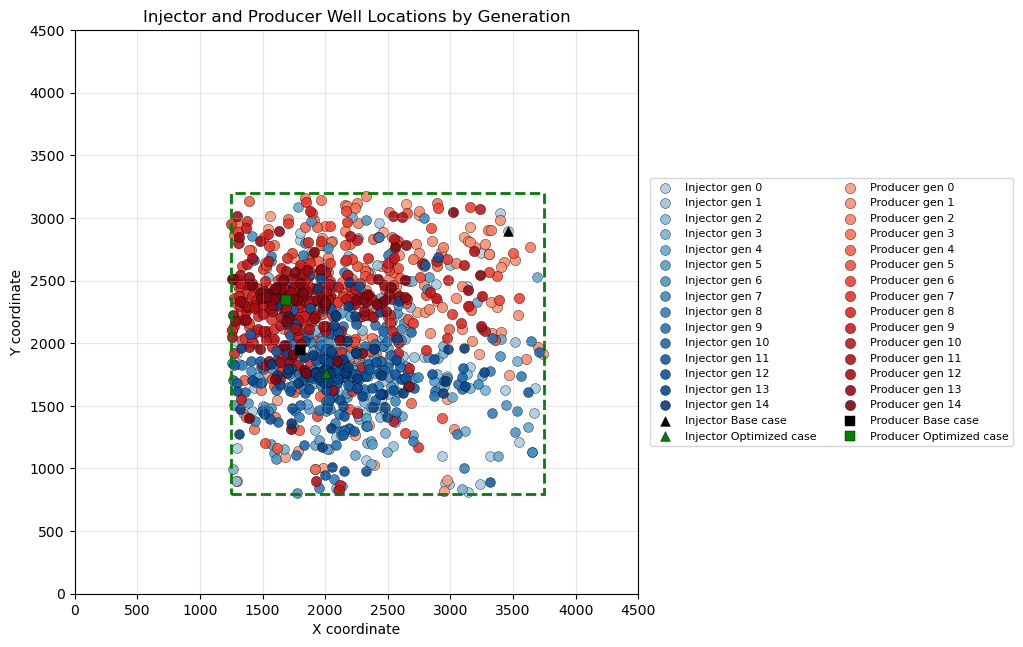

In [6]:
def plot_combined_well_locations(df_cv, cols):
    gen_col = cols["generation"]

    unique_gens = sorted(df_cv[gen_col].dropna().unique())
    blue_shades = generation_shades(len(unique_gens), cmap_name="Blues")
    red_shades = generation_shades(len(unique_gens), cmap_name="Reds")

    gen_to_blue = {g: blue_shades[i] for i, g in enumerate(unique_gens)}
    gen_to_red = {g: red_shades[i] for i, g in enumerate(unique_gens)}

    fig, ax = plt.subplots(figsize=(10, 7))

    for gen in unique_gens:
        df_gen = df_cv[df_cv[gen_col] == gen]

        ax.scatter(
            df_gen[cols["inj_x"]],
            df_gen[cols["inj_y"]],
            color=gen_to_blue[gen],
            marker="o",
            s=50,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9,
            label=f"Injector gen {gen}"
        )

        ax.scatter(
            df_gen[cols["prod_x"]],
            df_gen[cols["prod_y"]],
            color=gen_to_red[gen],
            marker="o",
            s=55,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9,
            label=f"Producer gen {gen}"
        )

    # draw optimizer search bounds rectangle if all limits are provided
    rect = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=2,
            label="Search bounds"
        )
    
    # Base case and optimized case points
    ax.scatter(
        base_case[cols["inj_x"]],
        base_case[cols["inj_y"]],
        color="black",
        marker="^",
        s=50,
        edgecolor="black",
        linewidth=0.3,
        zorder = 10,
        label="Injector Base case"
    )
    ax.scatter(
        base_case[cols["prod_x"]],
        base_case[cols["prod_y"]],
        color="black",
        marker="s",
        s=50,
        edgecolor="black",
        linewidth=0.3,
        zorder = 10,
        label="Producer Base case"
    )
    ax.scatter(
        optimized_case[cols["inj_x"]],
        optimized_case[cols["inj_y"]],
        color="green",
        marker="^",
        s=50,
        edgecolor="black",
        linewidth=0.3,
        zorder=11,
        label="Injector Optimized case"
        )
    ax.scatter(
        optimized_case[cols["prod_x"]],
        optimized_case[cols["prod_y"]],
        color="green",
        marker="s",
        s=50,
        edgecolor="black",
        linewidth=0.3,
        zorder=11,
        label="Producer Optimized case"
        )

    ax.add_patch(rect)
    ax.set_xlim(0, 4500)
    ax.set_ylim(0, 4500)
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_title("Injector and Producer Well Locations by Generation")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

    # reorder legend entries to group injectors and producers together
    handles, labels = ax.get_legend_handles_labels()
    # Separate injector and producer entries
    inj = [(h, l) for h, l in zip(handles, labels) if "Injector" in l]
    prod = [(h, l) for h, l in zip(handles, labels) if "Producer" in l]
    ordered = inj + prod
    handles_ordered, labels_ordered = zip(*ordered)
    ax.legend(handles_ordered, labels_ordered, loc="center left", fontsize=8, ncol=2, bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

plot_combined_well_locations(df_controlvector, cols)

### INJ scatter plot with HEAT contour

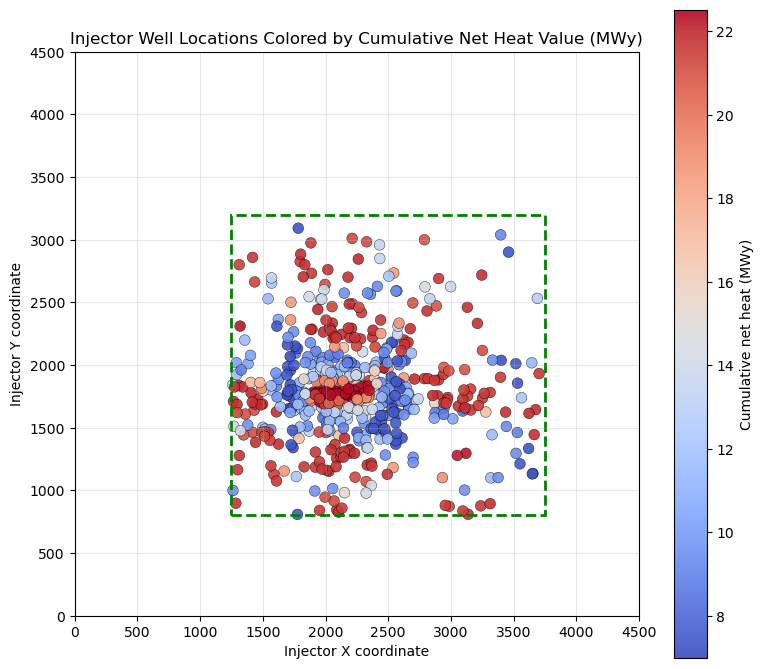

In [7]:
def plot_injector_by_objective(df_cv, cols):
    fig, ax = plt.subplots(figsize=(8, 7))

    norm = colors.Normalize(
        vmin=df_cv[cols["objective"]].min(),
        vmax=df_cv[cols["objective"]].max()
    )

    sc = ax.scatter(
        df_cv[cols["inj_x"]],
        df_cv[cols["inj_y"]],
        c=df_cv[cols["objective"]],
        cmap="coolwarm",
        norm=norm,
        s=60,
        edgecolor="black",
        linewidth=0.3,
        alpha=0.9
    )

    # draw optimizer search bounds rectangle if all limits are provided
    rect = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=2,
            label="Search bounds"
        )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Cumulative net heat (MWy)")

    ax.add_patch(rect)
    ax.set_xlim(0, 4500)
    ax.set_ylim(0, 4500)
    ax.set_xlabel("Injector X coordinate")
    ax.set_ylabel("Injector Y coordinate")
    ax.set_title("Injector Well Locations Colored by Cumulative Net Heat Value (MWy)")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

plot_injector_by_objective(df_controlvector, cols)

### PROD scatter plot with HEAT contour

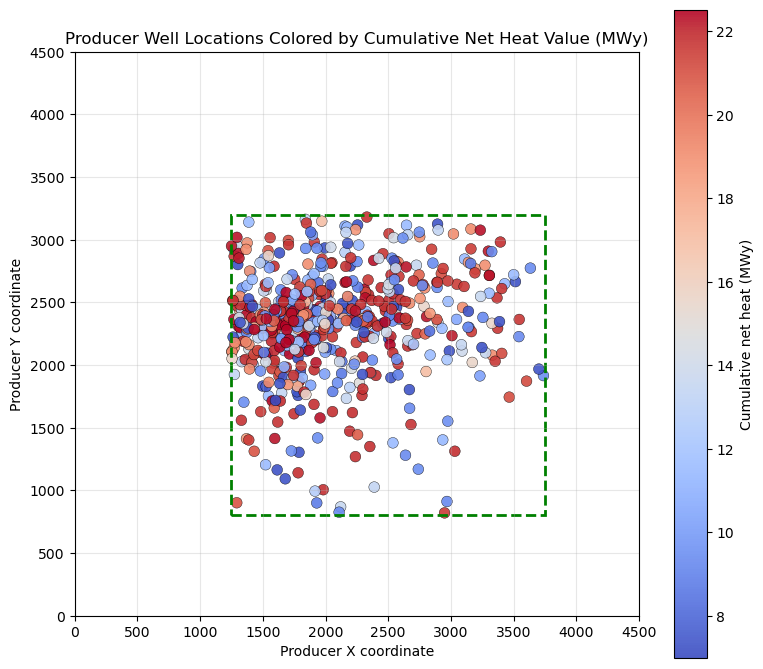

In [8]:
def plot_producer_by_objective(df_cv, cols):
    fig, ax = plt.subplots(figsize=(8, 7))

    norm = colors.Normalize(
        vmin=df_cv[cols["objective"]].min(),
        vmax=df_cv[cols["objective"]].max()
    )

    sc = ax.scatter(
        df_cv[cols["prod_x"]],
        df_cv[cols["prod_y"]],
        c=df_cv[cols["objective"]],
        cmap="coolwarm",
        norm=norm,
        s=60,
        edgecolor="black",
        linewidth=0.3,
        alpha=0.9
    )

    # draw optimizer search bounds rectangle if all limits are provided
    rect = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=2,
            label="Search bounds"
        )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Cumulative net heat (MWy)")

    ax.add_patch(rect)
    ax.set_xlim(0, 4500)
    ax.set_ylim(0, 4500)
    ax.set_xlabel("Producer X coordinate")
    ax.set_ylabel("Producer Y coordinate")
    ax.set_title("Producer Well Locations Colored by Cumulative Net Heat Value (MWy)")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

plot_producer_by_objective(df_controlvector, cols)

## OBJECTIVE FUNCTION PROGRESSION

### HELPERS for plotting

In [9]:
def prepare_generation_summary_for_plot(df_summary):
    df_summary = df_summary.copy()

    # required summary columns
    required_cols = ["generation", "global_best_Heat", "min_Heat", "max_Heat", "avg_Heat"]
    for col in required_cols:
        if col not in df_summary.columns:
            raise KeyError(f"Required column missing: {col}")

    # find individual heat columns dynamically
    ind_cols = [c for c in df_summary.columns if re.match(r"ind_\d+_Heat$", c)]

    if not ind_cols:
        raise ValueError("No individual heat columns found matching pattern 'ind_<n>_Heat'.")

    # sort by individual number
    ind_cols = sorted(ind_cols, key=lambda x: int(re.search(r"ind_(\d+)_Heat", x).group(1)))

    n_pop = len(ind_cols)
    print(f"Detected population size: {n_pop}")
    print(f"Individual columns: {ind_cols}")

    records = []

    for _, row in df_summary.iterrows():
        gen = int(row["generation"])
        base_index = gen * n_pop

        for i, ind_col in enumerate(ind_cols):
            records.append({
                "generation": gen,
                "population_global_index": base_index + i,
                "individual_in_generation": i,
                "ind_heat": row[ind_col],
                "global_best_Heat": row["global_best_Heat"],
                "max_Heat": row["max_Heat"],
                "avg_Heat": row["avg_Heat"],
                "min_Heat": row["min_Heat"],
            })

    df_plot = pd.DataFrame(records)
    return df_plot, ind_cols

### HEAT progression plot

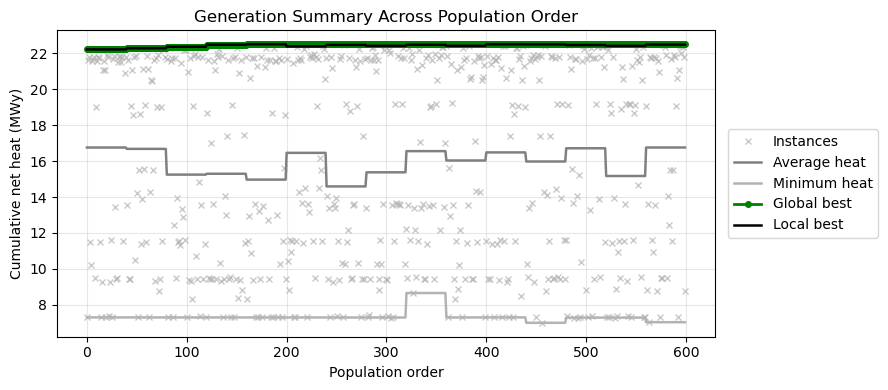

In [10]:
def plot_generation_summary_populationwise(df_plot):
    fig, ax = plt.subplots(figsize=(11, 4))

    x = df_plot["population_global_index"]

    # individual heats
    ax.plot(x,
            df_plot["ind_heat"],
            linestyle="None",
            marker="x",
            color="0.7",
            markersize=5,
            alpha=0.7,
            label="Instances")
    # average heat
    ax.plot(x,
            df_plot["avg_Heat"],
            linestyle="-",
            color="0.5",
            linewidth=1.8,
            label="Average heat")
    # minimum heat
    ax.plot(x,
            df_plot["min_Heat"],
            linestyle="-",
            color="0.7",
            linewidth=1.8,
            label="Minimum heat")

    # global best
    ax.plot(x,
            df_plot["global_best_Heat"],
            linestyle="-",
            marker="o",
            color="green",
            linewidth=2.0,
            markersize=4,
            label="Global best")

    # local best = max_Heat
    ax.plot(x,
            df_plot["max_Heat"],
            linestyle="-",
            color="black",
            linewidth=1.8,
            markersize=4,
            label="Local best")

    ax.set_xlabel("Population order")
    ax.set_ylabel("Cumulative net heat (MWy)")
    ax.set_title("Generation Summary Across Population Order")
    ax.grid(True, alpha=0.3)

    ax.legend(loc="center left",
              bbox_to_anchor=(1.02, 0.5),
              borderaxespad=0.0)

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

plot_generation_summary_populationwise(df_plot_summary)